# Enrolment

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_enrol = pd.read_csv('cleaned dataset/api_data_aadhar_enrolment.csv')
df_demo = pd.read_csv('cleaned dataset/api_data_aadhar_demographic.csv')
df_bio = pd.read_csv('cleaned dataset/api_data_aadhar_biometric.csv')

In [3]:
df_enrol['Type'] = 'Enrollment'
df_demo['Type'] = 'Demographic Update'
df_bio['Type'] = 'Biometric Update'

In [4]:
df_all = pd.concat([df_enrol, df_demo, df_bio], ignore_index=True)

display(df_all.shape)
display(df_all['Type'].value_counts())

(4938813, 9)

Type
Demographic Update    2071698
Biometric Update      1861108
Enrollment            1006007
Name: count, dtype: int64

In [5]:
dist_stats = df_enrol.groupby(['state', 'district'])[[ 'age between 0 and 5',  'age between 5 and 17', 'age 17 and above' ,'Type']].sum().reset_index()

display(dist_stats.head())

,state,district,age between 0 and 5,age between 5 and 17,age 17 and above,Type
0,andaman and nicobar islands,nicobar,65,11,0,EnrollmentEnrollmentEnrollmentEnrollmentEnroll...
1,andaman and nicobar islands,north and middle andaman,128,4,0,EnrollmentEnrollmentEnrollmentEnrollmentEnroll...
2,andaman and nicobar islands,south andaman,286,17,0,EnrollmentEnrollmentEnrollmentEnrollmentEnroll...
3,andhra pradesh,alluri sitharama raju,1105,116,34,EnrollmentEnrollmentEnrollmentEnrollmentEnroll...
4,andhra pradesh,anakapalli,523,12,8,EnrollmentEnrollmentEnrollmentEnrollmentEnroll...


In [6]:
dist_stats['Total Children'] = dist_stats['age between 0 and 5'] + dist_stats['age between 5 and 17']

Text(0.5, 0, 'Count of Adults')

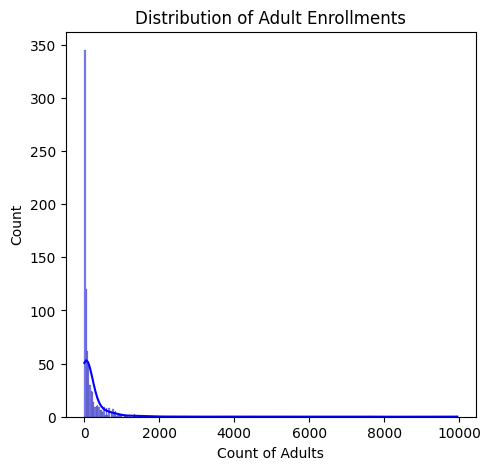

In [7]:
plt.figure(figsize=(18, 5))

# Plot A: Distribution of Adult Enrollments
plt.subplot(1, 3, 1)
sns.histplot(dist_stats['age 17 and above'], kde=True, color='blue')
plt.title('Distribution of Adult Enrollments')
plt.xlabel('Count of Adults')

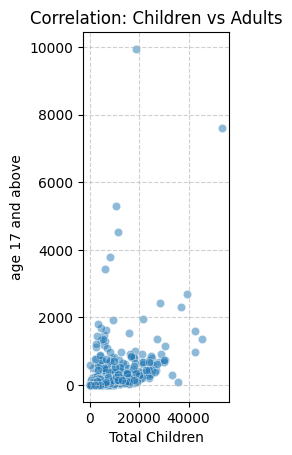

In [8]:
# Plot B: Scatter Plot (The "Organic Growth" Check)
# We expect districts with more children to also have more adults (Linear relationship)
plt.subplot(1, 3, 2)
sns.scatterplot(data=dist_stats, x='Total Children', y='age 17 and above', alpha=0.5)
plt.title('Correlation: Children vs Adults')
plt.grid(True, linestyle='--', alpha=0.6)
# Anomaly Note: Points far above the diagonal line are your "Ghost Districts"

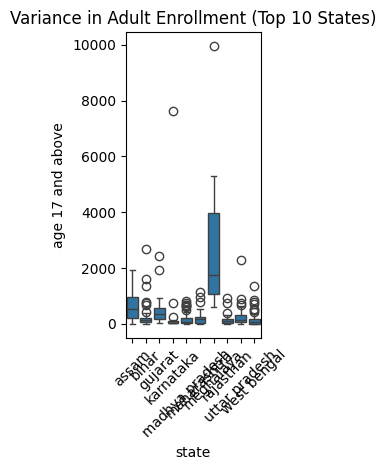

In [9]:
# Plot C: Boxplot by State (Spotting Outlier States)
plt.subplot(1, 3, 3)
# We take top 10 states by volume to avoid overcrowding the plot
top_states = dist_stats.groupby('state')['age 17 and above'].sum().nlargest(10).index
sns.boxplot(data=dist_stats[dist_stats['state'].isin(top_states)], x='state', y='age 17 and above')
plt.xticks(rotation=45)
plt.title('Variance in Adult Enrollment (Top 10 States)')

plt.tight_layout()
plt.show()

In [10]:
# --- 4. Statistical Summary (The Hard Numbers) ---
print("\n--- Descriptive Statistics (District Level) ---")
display(dist_stats.describe().round(2))

# Check Skewness
print("\n--- Skewness Check (0 = Normal, > 1 = Highly Skewed) ---")
print(dist_stats[['age 17 and above', 'Total Children']].skew())


--- Descriptive Statistics (District Level) ---


,age between 0 and 5,age between 5 and 17,age 17 and above,Total Children
count,806.00,806.00,806.00,806.00
mean,4400.70,2134.47,208.61,6535.17
std,4438.33,3323.14,609.29,7046.04
min,0.00,0.00,0.00,1.00
25%,1121.00,229.75,10.00,1505.00
50%,3327.50,840.00,45.00,4556.00
75%,6147.25,2647.00,168.00,8925.00
max,38343.00,28807.00,9948.00,53661.00



--- Skewness Check (0 = Normal, > 1 = Highly Skewed) ---
age 17 and above    9.388395
Total Children      2.191180
dtype: float64
